<a href="https://colab.research.google.com/github/unaizanouman/Colab-Codes/blob/main/SentimentAnalysisBrownUniversity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import nltk
from nltk.corpus import brown
import pandas as pd

In [4]:
nltk.download("brown")

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


True

In [5]:
brown.categories()


['adventure',
 'belles_lettres',
 'editorial',
 'fiction',
 'government',
 'hobbies',
 'humor',
 'learned',
 'lore',
 'mystery',
 'news',
 'religion',
 'reviews',
 'romance',
 'science_fiction']

In [6]:
docs=[" ".join(brown.words(fileid)) for fileid in brown.fileids()]
categories=[brown.categories(fileid)[0] for fileid in brown.fileids()]


In [7]:
df=pd.DataFrame({
    "text": docs,
    "category": categories
})

print(df.head())

                                                text category
0  The Fulton County Grand Jury said Friday an in...     news
1  Austin , Texas -- Committee approval of Gov. P...     news
2  Several defendants in the Summerdale police bu...     news
3  Oslo The most positive element to emerge from ...     news
4  East Providence should organize its civil defe...     news


In [8]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [9]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [10]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [11]:
def preprocess_text(text):
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenize and lowercase
    tokens = word_tokenize(text.lower())

    # Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)


In [12]:

df["cleaned_text"] = df["text"].apply(preprocess_text)

print(df[["text", "cleaned_text"]].head())

                                                text  \
0  The Fulton County Grand Jury said Friday an in...   
1  Austin , Texas -- Committee approval of Gov. P...   
2  Several defendants in the Summerdale police bu...   
3  Oslo The most positive element to emerge from ...   
4  East Providence should organize its civil defe...   

                                        cleaned_text  
0  fulton county grand jury said friday investiga...  
1  austin texas committee approval gov price dani...  
2  several defendant summerdale police burglary t...  
3  oslo positive element emerge oslo meeting nort...  
4  east providence organize civil defense setup b...  


In [13]:
import sys
from textblob import TextBlob

def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

df["sentiment_polarity"] = df["cleaned_text"].apply(get_sentiment)


In [14]:
def classify_sentiment(polarity):
    if polarity > 0:
        return "positive"
    elif polarity < 0:
        return "negative"
    else:
        return "neutral"

df["predicted_sentiment"] = df["sentiment_polarity"].apply(classify_sentiment)
print(df[["category", "predicted_sentiment"]].head())
print("---------------------------------------------")
print(df[["category", "predicted_sentiment"]])


  category predicted_sentiment
0     news            positive
1     news            positive
2     news            positive
3     news            positive
4     news            positive
---------------------------------------------
    category predicted_sentiment
0       news            positive
1       news            positive
2       news            positive
3       news            positive
4       news            positive
..       ...                 ...
495    humor            positive
496    humor            positive
497    humor            positive
498    humor            positive
499    humor            positive

[500 rows x 2 columns]


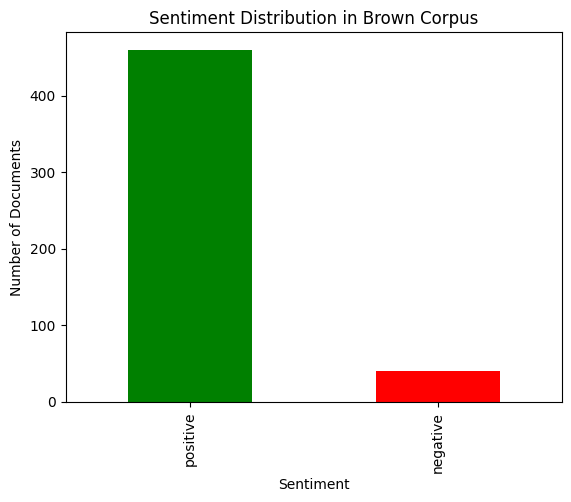

In [15]:
import matplotlib.pyplot as plt

df["predicted_sentiment"].value_counts().plot(kind="bar", color=["green","red"])

plt.title("Sentiment Distribution in Brown Corpus")
plt.xlabel("Sentiment")
plt.ylabel("Number of Documents")
plt.show()


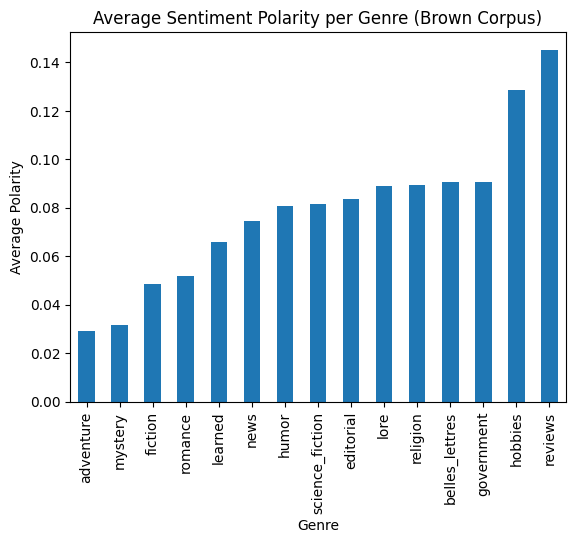

In [19]:
import matplotlib.pyplot as plt
avg_polarity.sort_values().plot(kind="bar")

plt.title("Average Sentiment Polarity per Genre (Brown Corpus)")
plt.xlabel("Genre")
plt.ylabel("Average Polarity")
plt.show()
